# Clustering bike sites

This notebook clusters the bike sites using the $k$-means based on few features. The clusters are then used for forecasting `total_count` in the next notebook. The clusters are determined by the training set cutoff `year <= 2022`.

The structure of the notebook is as follows:
- Create features and summary df using the balanced panel.
- Project raw lon/lat to appropriate Sydney map in metres `x_m`/`y_m`.
- Calculate silhouette scores and choose appropriate $k$.
- Export balanced panel merged with cluster labels.

In [1]:
import pandas as pd
import geopandas as gpd
import duckdb

import matplotlib.pyplot as plt
import contextily as ctx

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler

# warnings on Windows MKL
import warnings

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL",
    category=UserWarning,
)

## Create balanced summary table with features

In [2]:
# connect to local database
con = duckdb.connect("../data/transport_project.duckdb")
con.execute("SELECT * FROM bike_panel_wide_balanced LIMIT 5").fetch_df()

,site_id,survey_date,year,month,total_count,time_0600,time_0700,time_0800,time_1600,time_1700,time_1800,longitude,latitude
0,2,2010-03-01,2010,March,140,7,12,22,29,32,38,151.208601,-33.878286
1,2,2010-10-01,2010,October,84,5,16,23,12,13,15,151.208601,-33.878286
2,2,2011-03-01,2011,March,106,19,22,12,20,22,11,151.208601,-33.878286
3,2,2011-10-01,2011,October,243,40,45,39,32,53,34,151.208601,-33.878286
4,2,2012-03-01,2012,March,299,12,23,28,48,112,76,151.208601,-33.878286


In [3]:
# create avg, std, morning, evening, seasonal, stats summary
con.execute("""
    CREATE OR REPLACE TABLE site_summary_balanced AS
    SELECT
        site_id,
        COUNT(survey_date) AS n_surveys, 
        AVG(total_count) AS mean_total_count, 
        STDDEV_SAMP(total_count) AS std_total_count,
        AVG(CASE WHEN month = 'March' THEN total_count END) AS mean_march_count,
        AVG(CASE WHEN month = 'October' THEN total_count END) AS mean_october_count,
        AVG(time_0600 + time_0700 + time_0800) AS mean_morning_count,
        AVG(time_1600 + time_1700 + time_1800) AS mean_evening_count,
        AVG(
            CASE
                WHEN time_1600 + time_1700 + time_1800 > 0 THEN
                1.0 * (time_0600 + time_0700 + time_0800) / (time_1600 + time_1700 + time_1800)
                ELSE NULL
            END
        ) AS morning_evening_ratio,
        ANY_VALUE(longitude) AS longitude, ANY_VALUE(latitude) AS latitude
    FROM bike_panel_wide_balanced
    WHERE year <= 2022
    GROUP BY site_id
    ORDER BY site_id            
""")

con.execute("SELECT * FROM site_summary_balanced").fetch_df()

,site_id,n_surveys,mean_total_count,std_total_count,mean_march_count,mean_october_count,mean_morning_count,mean_evening_count,morning_evening_ratio,longitude,latitude
0,2,25,463.32,225.640149,410.250000,512.307692,174.92,288.40,0.637270,151.208601,-33.878286
1,4,25,797.40,164.294451,829.583333,767.692308,399.48,397.92,1.024202,151.209897,-33.873292
2,5,25,400.84,87.262382,404.333333,397.615385,185.08,215.76,0.898551,151.209083,-33.879797
3,8,25,251.80,76.645287,239.916667,262.769231,104.56,147.24,0.715469,151.207321,-33.865170
4,10,25,669.56,301.195407,621.333333,714.076923,314.00,355.56,0.924173,151.205093,-33.872817
...,...,...,...,...,...,...,...,...,...,...,...
62,95,25,398.96,153.586968,377.833333,418.461538,180.12,218.84,0.854642,151.207260,-33.903076
63,96,25,396.36,178.004653,396.750000,396.000000,189.96,206.40,0.910690,151.202331,-33.898395
64,98,25,104.52,25.095019,99.583333,109.076923,46.60,57.92,0.876527,151.216737,-33.872388
65,99,25,115.00,36.305417,108.083333,121.384615,59.12,55.88,1.095391,151.211133,-33.911924


In [4]:
# create march - october feature
con.execute("""
    CREATE OR REPLACE TABLE mean_march_october_diff_table AS
    WITH yearly_mar_oct_diffs AS (
        SELECT
            site_id, year,
            SUM(CASE WHEN month = 'March' THEN total_count END)
                - SUM(CASE WHEN month = 'October' THEN total_count END) 
                AS march_october_diff
        FROM bike_panel_wide_balanced
        GROUP BY site_id, year
        HAVING COUNT(DISTINCT month) = 2     
    )
    SELECT 
        site_id, 
        AVG(march_october_diff) AS mean_march_october_diff
    FROM yearly_mar_oct_diffs
    WHERE year <= 2022
    GROUP BY site_id
    ORDER BY site_id
""")

con.execute("SELECT * FROM mean_march_october_diff_table LIMIT 5").fetch_df()

,site_id,mean_march_october_diff
0,2,-82.083333
1,4,67.333333
2,5,9.333333
3,8,-28.000000
4,10,-60.666667


In [5]:
# make clustering table
con.execute("""
    CREATE OR REPLACE TABLE clustering_panel_balanced AS
    SELECT
        s.site_id, s.n_surveys,
        s.mean_total_count, s.std_total_count,
        s.mean_march_count, s.mean_october_count, m.mean_march_october_diff,
        s.mean_morning_count, s.mean_evening_count, s.morning_evening_ratio,
        s.longitude, s.latitude
    FROM site_summary_balanced as s
    INNER JOIN mean_march_october_diff_table as m
        ON s.site_id = m.site_id
    ORDER BY site_id
""")

# turn to df
df_sites = con.execute("SELECT * FROM clustering_panel_balanced").fetch_df()
df_sites.head()

,site_id,n_surveys,mean_total_count,std_total_count,mean_march_count,mean_october_count,mean_march_october_diff,mean_morning_count,mean_evening_count,morning_evening_ratio,longitude,latitude
0,2,25,463.32,225.640149,410.250000,512.307692,-82.083333,174.92,288.40,0.637270,151.208601,-33.878286
1,4,25,797.40,164.294451,829.583333,767.692308,67.333333,399.48,397.92,1.024202,151.209897,-33.873292
2,5,25,400.84,87.262382,404.333333,397.615385,9.333333,185.08,215.76,0.898551,151.209083,-33.879797
3,8,25,251.80,76.645287,239.916667,262.769231,-28.000000,104.56,147.24,0.715469,151.207321,-33.865170
4,10,25,669.56,301.195407,621.333333,714.076923,-60.666667,314.00,355.56,0.924173,151.205093,-33.872817


In [6]:
df_sites.describe()

,site_id,n_surveys,mean_total_count,std_total_count,mean_march_count,mean_october_count,mean_march_october_diff,mean_morning_count,mean_evening_count,morning_evening_ratio,longitude,latitude
count,67.000000,67.0,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000
mean,52.955224,25.0,572.180299,158.714151,559.529851,583.857635,-19.733831,284.880597,287.299701,0.967227,151.202066,-33.886339
std,29.282031,0.0,484.952219,129.669679,476.060073,494.002846,44.313851,266.578945,224.892144,0.241138,0.013627,0.015686
min,2.000000,25.0,78.000000,17.247995,78.416667,77.615385,-193.166667,32.280000,45.720000,0.545811,151.174816,-33.922914
25%,27.500000,25.0,250.740000,62.141827,251.875000,247.538462,-39.541667,106.740000,136.560000,0.849237,151.192967,-33.897379
50%,54.000000,25.0,396.360000,120.366205,391.916667,397.615385,-13.333333,185.080000,206.400000,0.910690,151.203631,-33.884410
75%,78.500000,25.0,719.760000,206.893344,678.791667,740.884615,7.458333,340.100000,389.020000,1.052824,151.211546,-33.873947
max,100.000000,25.0,2018.160000,522.843900,1989.250000,2044.846154,102.750000,1198.600000,1010.800000,2.093607,151.233090,-33.857023


## Project lon/lat coordinates into EPSG:7856

EPSG:7856 by in large contains Australia

In [7]:
# convert lon/lat to metres
gdf_sites = gpd.GeoDataFrame(
    df_sites, 
    geometry=gpd.points_from_xy(df_sites["longitude"], df_sites["latitude"]),
    crs="EPSG:4326" # WGS84 - lat/lon
).to_crs("EPSG:7856") # project to metre-based CRS

# coords in metres
gdf_sites["x_m"] = gdf_sites.geometry.x
gdf_sites["y_m"] = gdf_sites.geometry.y

# choose features
cluster_features = [
    "mean_total_count", "std_total_count",
    "morning_evening_ratio",
    "mean_march_october_diff",
    "x_m", "y_m"
]

X = gdf_sites[cluster_features].copy()
X.head()

,mean_total_count,std_total_count,morning_evening_ratio,mean_march_october_diff,x_m,y_m
0,463.32,225.640149,0.637270,-82.083333,334322.330198,6.249895e+06
1,797.40,164.294451,1.024202,67.333333,334432.545398,6.250451e+06
2,400.84,87.262382,0.898551,9.333333,334369.852498,6.249728e+06
3,251.80,76.645287,0.715469,-28.000000,334178.533498,6.251348e+06
4,669.56,301.195407,0.924173,-60.666667,333987.257198,6.250496e+06


In [8]:
# z-score the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Calcualte silhouette scores and choose $k$

In [9]:
# silhouette score to determine k
scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append((k, score))

scores

[(2, 0.3729596116577169),
 (3, 0.24480070179917215),
 (4, 0.2639692099433911),
 (5, 0.2550286738832649),
 (6, 0.24719638135307834)]

In [10]:
# choose k = 4/5 have better scores but less interpretable or seem redundant than k = 3
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=20)
gdf_sites["cluster"] = km.fit_predict(X_scaled)
gdf_sites[["site_id", "cluster"]].head()

,site_id,cluster
0,2,2
1,4,0
2,5,0
3,8,0
4,10,1


In [11]:
# relabel clusters ascendingly on the median value of mean_total_count
cluster_order = gdf_sites.groupby("cluster")["mean_total_count"].median().sort_values().index

cluster_relabel_map = {
    old_cluster: new_cluster
    for new_cluster, old_cluster in enumerate(cluster_order)
}

gdf_sites["cluster"] = gdf_sites["cluster"].map(cluster_relabel_map)
gdf_sites.groupby("cluster")["mean_total_count"].median()

cluster
0     349.16
1     360.38
2    1517.52
Name: mean_total_count, dtype: float64

In [12]:
# helper to create cluster summary table
def make_cluster_summary_table(
    gdf_sites,
    interpretation_map=None,
    examples_map=None
):
    agg_func = "median"

    summary = (
        gdf_sites.groupby("cluster")
        .agg(
            n_sites=("site_id", "nunique"),
            mean_count=("mean_total_count", agg_func),
            std_count=("std_total_count", agg_func),
            morning_evening_ratio=("morning_evening_ratio", agg_func),
            mar_oct_diff=("mean_march_october_diff", agg_func),
        ).reset_index()
    )

    summary["Interpretation"] = summary["cluster"].map(interpretation_map)
    summary["Example routes/sites"] = summary["cluster"].map(examples_map)

    summary = summary.rename(columns={
        "cluster": "Cluster",
        "mean_count": "Mean count",
        "std_count": "Std count",
        "morning_evening_ratio": "Morning/Evening ratio",
        "mar_oct_diff": "Mar–Oct difference",
    })

    summary = summary[
        [
            "Cluster",
            "Interpretation",
            "n_sites",
            "Mean count",
            "Std count",
            "Morning/Evening ratio",
            "Mar–Oct difference",
            "Example routes/sites",
        ]
    ]

    return summary

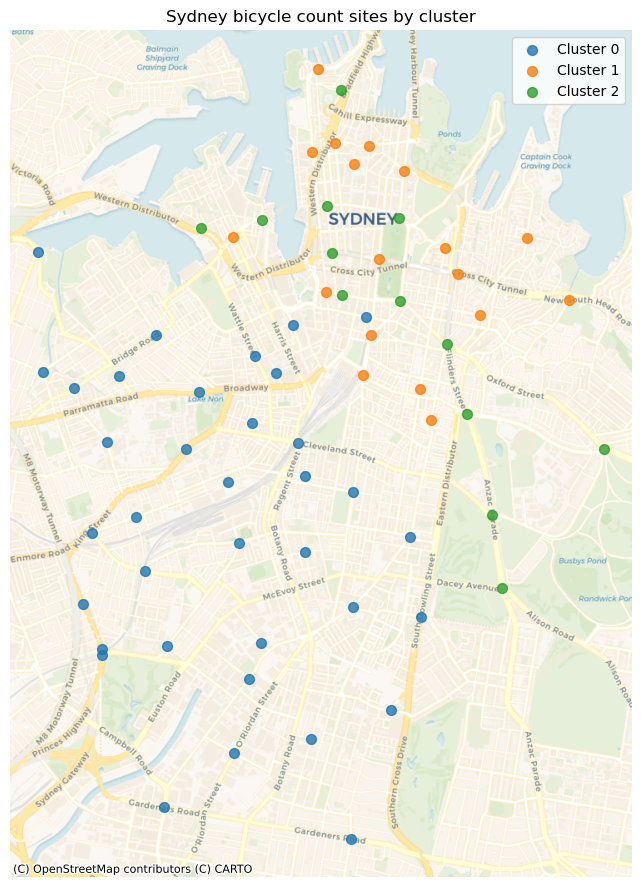

In [13]:
# overlay the cluster points onto basemap
# reproject to EPSG:3857 which is used by contextily
gdf_sites_web = gdf_sites.to_crs("EPSG:3857")

fig, ax = plt.subplots(figsize=(11, 11))

for c in sorted(gdf_sites_web["cluster"].unique()):
    d = gdf_sites_web[gdf_sites_web["cluster"] == c]
    d.plot(
        ax=ax,
        markersize=50,
        alpha=0.8,
        label=f"Cluster {c}"
    )

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Voyager
)

ax.set_title("Sydney bicycle count sites by cluster")
ax.legend()
ax.set_axis_off()

plt.savefig("../outputs/sites_cluster_map.png", format="png", bbox_inches="tight")
plt.show()

In [14]:
# make the table with relevant information
interpretation_map = {
    0: "Southwest peripheral sites",
    1: "Inner-city connector streets",
    2: "High-volume commuter corridors",
}

examples_map = {
    0: "Princes Hwy / Parramatta Rd / Eastern Dist",
    1: "Bridge St / Elizabeth St",
    2: "Harbour Brg / Pyrmont Brg / Anzac Pde",
}

cluster_summary = make_cluster_summary_table(
    gdf_sites,
    interpretation_map=interpretation_map,
    examples_map=examples_map,
)

cluster_summary

,Cluster,Interpretation,n_sites,Mean count,Std count,Morning/Evening ratio,Mar–Oct difference,Example routes/sites
0,0,Southwest peripheral sites,36,349.16,89.068429,0.890449,-14.708333,Princes Hwy / Parramatta Rd / Eastern Dist
1,1,Inner-city connector streets,18,360.38,95.217699,0.943844,3.916667,Bridge St / Elizabeth St
2,2,High-volume commuter corridors,13,1517.52,381.125080,1.125185,-60.666667,Harbour Brg / Pyrmont Brg / Anzac Pde


In [ ]:
# print(cluster_summary.round({"Std count": 2, "Morning/Evening ratio": 2, "Mar–Oct difference": 2}).to_markdown(index=False))
# cluster_summary.to_csv("../power_bi/exports/cluster_interpretation.csv")

## Export balanced panel with cluster labels

In [16]:
# merge to balanced panel to make research panel
df_sites_cluster = pd.DataFrame(gdf_sites[["site_id", "cluster"]])
con.register("sites_cluster_table", df_sites_cluster)

con.execute("""
    CREATE OR REPLACE TABLE research_panel AS
    SELECT b.*, s.cluster
    FROM bike_panel_wide_balanced AS b
    INNER JOIN sites_cluster_table AS s
        ON b.site_id = s.site_id
    ORDER BY b.site_id, b.survey_date
""")

con.execute("SELECT * FROM research_panel LIMIT 5").fetch_df()

,site_id,survey_date,year,month,total_count,time_0600,time_0700,time_0800,time_1600,time_1700,time_1800,longitude,latitude,cluster
0,2,2010-03-01,2010,March,140,7,12,22,29,32,38,151.208601,-33.878286,0
1,2,2010-10-01,2010,October,84,5,16,23,12,13,15,151.208601,-33.878286,0
2,2,2011-03-01,2011,March,106,19,22,12,20,22,11,151.208601,-33.878286,0
3,2,2011-10-01,2011,October,243,40,45,39,32,53,34,151.208601,-33.878286,0
4,2,2012-03-01,2012,March,299,12,23,28,48,112,76,151.208601,-33.878286,0
